# Hovmoller FWC and SIC distribution

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41637")
client

<Client: 'tcp://127.0.0.1:41637' processes=8 threads=32, memory=123.95 GiB>

**PROCEDURE:**

1. Select days after sea ice minimum each year.
2. Mask grid cells where SIC>15% at minimum.
3. Calculate FWC in each grid cell, then bin grid cells (e.g., 0.1 m increments).
4. For each FWC bin and timestep, compute percent grid cells >15% SIC or compute mean SIC.

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## Plot SIC time series in Beaufort box

In [9]:
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [49]:
ice_select = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))*beaufort_area

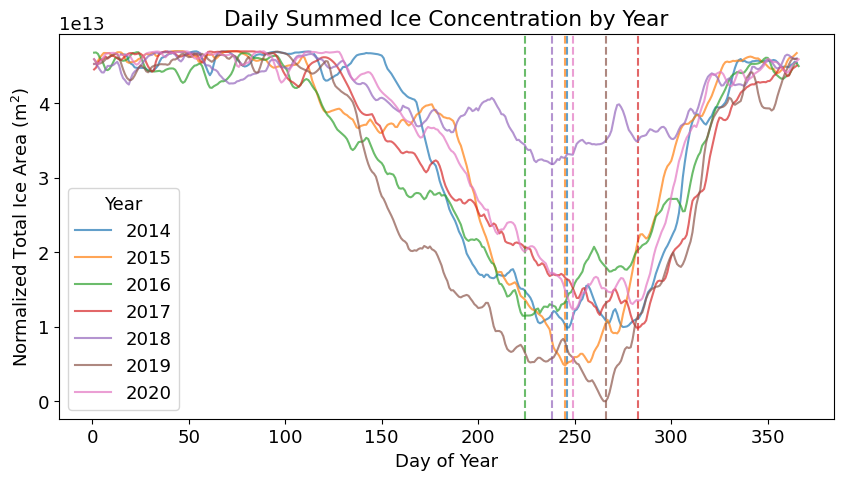

In [52]:
plt.rcParams['font.size'] = 13

# Sum over spatial dimensions (i, j) for daily total ice concentration
daily_ice_sum = ice_select.sum(dim=['i', 'j'])
daily_ice_sum = daily_ice_sum.where(daily_ice_sum != 0)
daily_ice_sum = daily_ice_sum - daily_ice_sum.min() # normalize

# Group by year
grouped = daily_ice_sum.groupby("time.year")

# Plot
plt.figure(figsize=(10, 5))

for year, data in grouped:
    doy = data['time'].dt.dayofyear  # Day of year
    line, = plt.plot(doy, data, label=str(year), alpha=0.7)  # Plot time series

    # Find the day of the minimum value for the year
    min_day = doy[data.argmin().values]
    
    # Plot vertical line with the same color as the corresponding time series
    plt.axvline(min_day, color=line.get_color(), linestyle='--', alpha=0.7)

plt.xlabel('Day of Year')
plt.ylabel('Normalized Total Ice Area (m$^2$)')
plt.title('Daily Summed Ice Concentration by Year')
plt.legend(title='Year')
plt.show()

## 1. Select days after sea ice minimum each year

In [50]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [18]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
ice_area_beaufort = ice_beaufort*beaufort_area

In [22]:
# sum over spatial dimensions (i, j) for daily total ice concentration
daily_ice_sum = ice_area_beaufort.sum(dim=['i', 'j'])
daily_ice_sum = daily_ice_sum.where(daily_ice_sum != 0)

# group by year
grouped = daily_ice_sum.groupby("time.year")

# find the day of the minimum value for the year
min_day = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values
    min_day.append(min_day_tmp)
    print(min_day_tmp)

2014-09-03T12:00:00.000000000
2015-09-02T12:00:00.000000000
2016-08-11T12:00:00.000000000
2017-10-10T12:00:00.000000000
2018-08-27T12:00:00.000000000
2019-09-23T12:00:00.000000000
2020-09-05T12:00:00.000000000


In [44]:
# select days after sea ice minimum for SIC and salinity
ice_yr = ice_beaufort.sel(time=slice(min_day[0],str(min_day[0])[0:4]+'-12-31'))
salt_yr = salt_beaufort.sel(time=slice(min_day[0],str(min_day[0])[0:4]+'-12-31')).isel(k=slice(0,8)) # only upper 12 m

In [51]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8))
fwc_beaufort_yr = calculate_fwc(salt_yr, salt_ref, dz)

In [53]:
# mask grid cells where SIC>15% on ice minimum date
ice_yr_masked = ice_yr.where(ice_yr.isel(time=0)<15)
fwc_yr_masked = fwc_beaufort_yr.where(ice_yr.isel(time=0)<15)

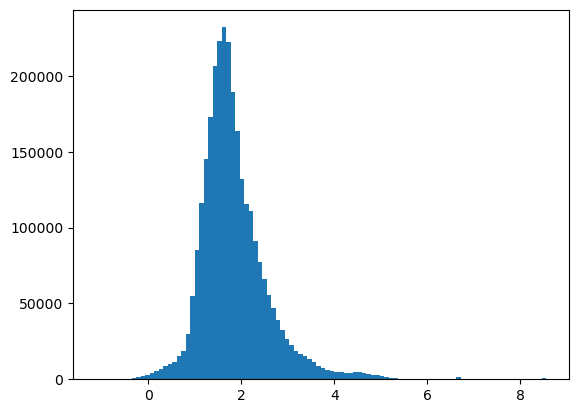

In [62]:
plt.hist(np.ravel(fwc_yr_masked.values),100);

In [74]:
# define FWC bins
fwc_bins = np.linspace(0,8,99)
fwc_bins = np.append(fwc_bins, 9) # total of 100

In [75]:
len(fwc_bins)

100

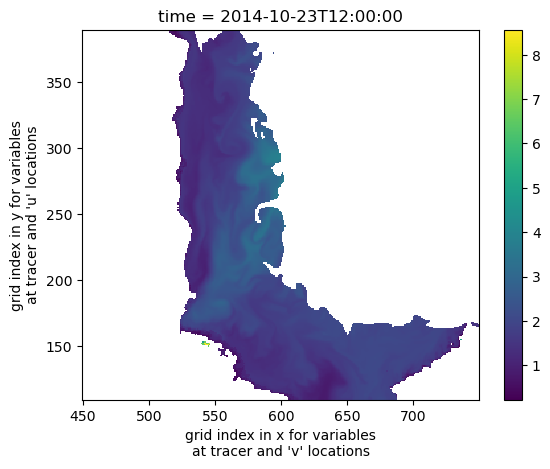

In [76]:
fwc_yr_masked.isel(time=50).plot();

In [134]:
# bin each grid cell into FWC intervals

# define your bin intervals
fwc_bins = np.linspace(0, 8, 100)  # 100 bin intervals from 0 to 8 (you can adjust this)

# use np.digitize to bin the values according to fwc_bins
fwc_binned_yr = np.digitize(fwc_yr_masked, fwc_bins, right=False)

In [135]:
fwc_binned_yr.shape

(120, 280, 300)

In [136]:
# sanity check
print(bin_indices[0,110,145]) # index = 70
print(fwc_bins[69:71])
print(fwc_yr_masked.values[0,110,145]) # looks good

70
[5.57575758 5.65656566]
5.590642171289728


In [137]:
fwc_binned_da = xr.DataArray(data = fwc_binned_yr, dims=['time', 'j', 'i'],\
                        coords={'time': fwc_yr_masked.time.values, 'j': fwc_yr_masked.j.values, 'i': fwc_yr_masked.i.values})

In [138]:
# mask out land and sea ice
fwc_binned_da = fwc_binned_da.where(HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).maskC).where(ice_yr.isel(time=0)<15)

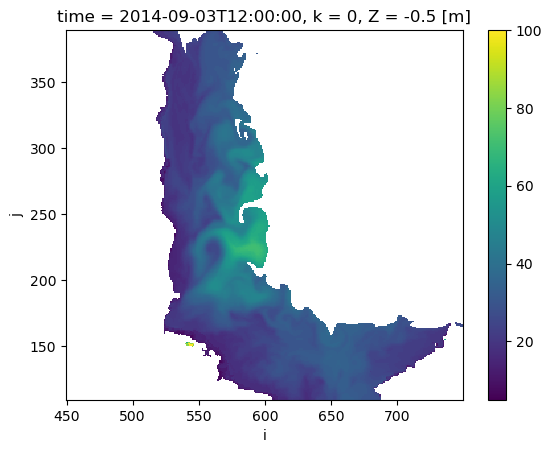

In [139]:
fwc_binned_da.isel(time=0).plot();

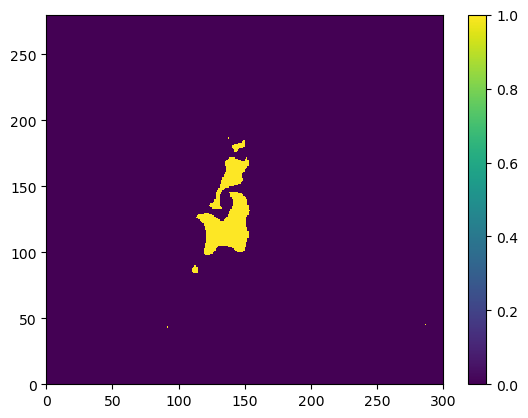

In [117]:
plt.pcolormesh((bin_indices[0,:,:]>50) & (bin_indices[0,:,:]<80))
plt.colorbar();

In [141]:
ice_yr_masked.shape

(120, 280, 300)

In [142]:
fwc_binned_da.shape

(120, 280, 300)

In [149]:
# group by bins and calculate % grid cells over 15%
ice_grouped_mean = ice_yr_masked.groupby(fwc_binned_da).mean(dims=['i','j'])

In [150]:
ice_grouped_mean

<xarray.DataArray 'SIarea' (group: 74)> Size: 592B
dask.array<groupby_nanmean, shape=(74,), dtype=float64, chunksize=(74,), chunktype=numpy.ndarray>
Coordinates:
    k        int32 4B 0
    Z        float32 4B ...
  * group    (group) float64 592B 0.0 1.0 2.0 3.0 4.0 ... 70.0 71.0 83.0 100.0

## 2. Mask grid cells where SIC>15% at minimum

## 3. Calculate FWC in each grid cell, then bin grid cells (e.g., 0.1 m increments)